## 1. Data exploration

In [1]:
import pandas as pd
import additional_functions_KI as af

url = '/Users/k.yukhlina/IronHack/Week_4/Day_1/archive/airnb.csv'
airbnb_df = pd.read_csv(url, encoding='utf8')
airbnb_df

,Title,Detail,Date,Price(in dollar),Offer price(in dollar),Review and rating,Number of bed
0,"Chalet in Skykomish, Washington, US",Sky Haus - A-Frame Cabin,Jun 11 - 16,306.00,229.00,4.85 (531),4 beds
1,"Cabin in Hancock, New York, US",The Catskill A-Frame - Mid-Century Modern Cabin,Jun 6 - 11,485.00,170.00,4.77 (146),4 beds
2,"Cabin in West Farmington, Ohio, US",The Triangle: A-Frame Cabin for your city retreat,Jul 9 - 14,119.00,522.00,4.91 (515),4 beds
3,"Home in Blue Ridge, Georgia, US",*Summer Sizzle* 5 Min to Blue Ridge* Pets* Hot...,Jun 11 - 16,192.00,348.00,4.94 (88),5 beds
4,"Treehouse in Grandview, Texas, US",Luxury Treehouse Couples Getaway w/ Peaceful V...,Jun 4 - 9,232.00,196.00,4.99 (222),1 queen bed
...,...,...,...,...,...,...,...
948,Guest suite in Lake Worth,The Garden Suite at the Historic Chateau Bleu,May 1 - 6,141.00,NaN,4.85 (82),1 king bed
949,Room in Kissimmee,Private Room in Orlando/Kissimmee (2Twins) T1,May 1 - 6,43.00,NaN,4.9 (300),1 king bed
950,Guesthouse in San Antonio,Casa Alexander,May 1 - 6,73.00,NaN,4.92 (282),5 beds
951,Apartment in Englewood,BEACH FRONT Unit w/ Pool Sandy Toe's # 5,May 7 - 12,233.00,NaN,4.96 (318),4 beds


In [2]:
airbnb_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Title                   953 non-null    str  
 1   Detail                  953 non-null    str  
 2   Date                    953 non-null    str  
 3   Price(in dollar)        953 non-null    str  
 4   Offer price(in dollar)  166 non-null    str  
 5   Review and rating       947 non-null    str  
 6   Number of bed           953 non-null    str  
dtypes: str(7)
memory usage: 52.2 KB


In [3]:
airbnb_df.to_string()

'                                                           Title                                                                                                                             Detail            Date Price(in dollar) Offer price(in dollar) Review and rating  Number of bed\n0                            Chalet in Skykomish, Washington, US                                                                                                           Sky Haus - A-Frame Cabin     Jun 11 - 16           306.00                 229.00        4.85 (531)         4 beds\n1                                 Cabin in Hancock, New York, US                                                                                    The Catskill A-Frame - Mid-Century Modern Cabin      Jun 6 - 11           485.00                 170.00        4.77 (146)         4 beds\n2                             Cabin in West Farmington, Ohio, US                                                                             

In [4]:
airbnb_df.dtypes

Title                     str
Detail                    str
Date                      str
Price(in dollar)          str
Offer price(in dollar)    str
Review and rating         str
Number of bed             str
dtype: object

In [5]:
airbnb_df.shape

(953, 7)

In [6]:
airbnb_df.nunique()

Title                     756
Detail                    839
Date                      204
Price(in dollar)          322
Offer price(in dollar)    108
Review and rating         754
Number of bed              33
dtype: int64

In [7]:
airbnb_df.isna().sum()

Title                       0
Detail                      0
Date                        0
Price(in dollar)            0
Offer price(in dollar)    787
Review and rating           6
Number of bed               0
dtype: int64

**Initial Data Quality Assessment** 

1. We need to convert all data into ***str*** and after we need to convert
- 'Price(in dollar)' and 'Offer price(in dollar)' into ***float*** to use in filters or calculations
- 'Review and rating' we need to split into  'rating' and 'amount of answers' to use data in filters or calculations
- 'rating' should become a ***float*** and  'amount of answers' should become an ***int*** 
- 'Offer price(in dollar)' - we don't need this column because it contains small anount of data

2. To investigate if we can use "Number of bed" column as categotial. We need to clean this column and check duplicates

## 2. Data Cleaning and Formating

In [9]:
airbnb_df_copy = airbnb_df.copy()
airbnb_df_copy = af.columns_formating(airbnb_df_copy)
airbnb_df_copy["price(in_dollar)"] = (airbnb_df_copy["price(in_dollar)"]).str.strip().str.replace(',', '', regex=True)
airbnb_df_copy["price(in_dollar)"]

0      306.00
1      485.00
2      119.00
3      192.00
4      232.00
        ...  
948    141.00
949     43.00
950     73.00
951    233.00
952    106.00
Name: price(in_dollar), Length: 953, dtype: str

In [10]:
airbnb_df_copy["price(in_dollar)"] = airbnb_df_copy["price(in_dollar)"].fillna(0).map(float)
airbnb_df_copy["price(in_dollar)"]

0      306.0
1      485.0
2      119.0
3      192.0
4      232.0
       ...  
948    141.0
949     43.0
950     73.0
951    233.0
952    106.0
Name: price(in_dollar), Length: 953, dtype: float64

2.2 Cleaning and formating 

In [11]:
airbnb_df_copy.dtypes

title                         str
detail                        str
date                          str
price(in_dollar)          float64
offer_price(in_dollar)        str
review_and_rating             str
number_of_bed                 str
dtype: object

In [12]:
airbnb_df_copy["number_of_bed"].value_counts()

number_of_bed
2 beds           221
3 beds           117
1 queen bed      105
1 bed            100
1 king bed        87
4 beds            63
1 double bed      55
2 queen beds      49
2 double beds     24
2 king beds       21
1 sofa bed        19
5 beds            17
6 beds            17
3 queen beds       8
2 single beds      7
9 beds             5
4 double beds      5
3 double beds      5
4 single beds      4
8 beds             4
7 beds             3
2 sofa beds        3
1 bunk bed         3
5 double beds      2
4 sofa beds        1
11 beds            1
22 beds            1
3 king beds        1
4 king beds        1
17 beds            1
4 queen beds       1
13 beds            1
10 beds            1
Name: count, dtype: int64

In [13]:
airbnb_df_copy["number_of_bed"] = af.clear_data(airbnb_df_copy["number_of_bed"]) #there is an external function "clear_data" located in external file


The cleaning doesn't help to decrease amount of values.

**Conclusion.**
We can't categorise data using this column, because this column has to much variants

In [14]:
airbnb_df_copy["review_and_rating"].value_counts()

review_and_rating
New           16
5.0 (11)       6
5.0 (9)        6
5.0 (4)        5
5.0 (13)       5
              ..
4.85 (82)      1
4.9 (300)      1
4.92 (282)     1
4.96 (318)     1
4.85 (97)      1
Name: count, Length: 754, dtype: int64

In [15]:
airbnb_df_copy[['rating_value', 'amount_of_answers']] = airbnb_df_copy.review_and_rating.str.split(" ", expand=True)

In [16]:
airbnb_df_copy

,title,detail,date,price(in_dollar),offer_price(in_dollar),review_and_rating,number_of_bed,rating_value,amount_of_answers
0,"Chalet in Skykomish, Washington, US",Sky Haus - A-Frame Cabin,Jun 11 - 16,306.0,229.00,4.85 (531),4 beds,4.85,(531)
1,"Cabin in Hancock, New York, US",The Catskill A-Frame - Mid-Century Modern Cabin,Jun 6 - 11,485.0,170.00,4.77 (146),4 beds,4.77,(146)
2,"Cabin in West Farmington, Ohio, US",The Triangle: A-Frame Cabin for your city retreat,Jul 9 - 14,119.0,522.00,4.91 (515),4 beds,4.91,(515)
3,"Home in Blue Ridge, Georgia, US",*Summer Sizzle* 5 Min to Blue Ridge* Pets* Hot...,Jun 11 - 16,192.0,348.00,4.94 (88),5 beds,4.94,(88)
4,"Treehouse in Grandview, Texas, US",Luxury Treehouse Couples Getaway w/ Peaceful V...,Jun 4 - 9,232.0,196.00,4.99 (222),1 queen bed,4.99,(222)
...,...,...,...,...,...,...,...,...,...
948,Guest suite in Lake Worth,The Garden Suite at the Historic Chateau Bleu,May 1 - 6,141.0,NaN,4.85 (82),1 king bed,4.85,(82)
949,Room in Kissimmee,Private Room in Orlando/Kissimmee (2Twins) T1,May 1 - 6,43.0,NaN,4.9 (300),1 king bed,4.9,(300)
950,Guesthouse in San Antonio,Casa Alexander,May 1 - 6,73.0,NaN,4.92 (282),5 beds,4.92,(282)
951,Apartment in Englewood,BEACH FRONT Unit w/ Pool Sandy Toe's # 5,May 7 - 12,233.0,NaN,4.96 (318),4 beds,4.96,(318)


In [17]:
airbnb_df_copy["amount_of_answers"] = airbnb_df_copy["amount_of_answers"].str.replace(r'[()]', '', regex=True)

In [18]:
airbnb_df_copy

,title,detail,date,price(in_dollar),offer_price(in_dollar),review_and_rating,number_of_bed,rating_value,amount_of_answers
0,"Chalet in Skykomish, Washington, US",Sky Haus - A-Frame Cabin,Jun 11 - 16,306.0,229.00,4.85 (531),4 beds,4.85,531
1,"Cabin in Hancock, New York, US",The Catskill A-Frame - Mid-Century Modern Cabin,Jun 6 - 11,485.0,170.00,4.77 (146),4 beds,4.77,146
2,"Cabin in West Farmington, Ohio, US",The Triangle: A-Frame Cabin for your city retreat,Jul 9 - 14,119.0,522.00,4.91 (515),4 beds,4.91,515
3,"Home in Blue Ridge, Georgia, US",*Summer Sizzle* 5 Min to Blue Ridge* Pets* Hot...,Jun 11 - 16,192.0,348.00,4.94 (88),5 beds,4.94,88
4,"Treehouse in Grandview, Texas, US",Luxury Treehouse Couples Getaway w/ Peaceful V...,Jun 4 - 9,232.0,196.00,4.99 (222),1 queen bed,4.99,222
...,...,...,...,...,...,...,...,...,...
948,Guest suite in Lake Worth,The Garden Suite at the Historic Chateau Bleu,May 1 - 6,141.0,NaN,4.85 (82),1 king bed,4.85,82
949,Room in Kissimmee,Private Room in Orlando/Kissimmee (2Twins) T1,May 1 - 6,43.0,NaN,4.9 (300),1 king bed,4.9,300
950,Guesthouse in San Antonio,Casa Alexander,May 1 - 6,73.0,NaN,4.92 (282),5 beds,4.92,282
951,Apartment in Englewood,BEACH FRONT Unit w/ Pool Sandy Toe's # 5,May 7 - 12,233.0,NaN,4.96 (318),4 beds,4.96,318


In [34]:
airbnb_df_copy[['property_type', 'location']] = airbnb_df_copy.title.str.split(" in ", expand=True)
airbnb_df_copy

,title,detail,date,price(in_dollar),offer_price(in_dollar),review_and_rating,number_of_bed,rating_value,amount_of_answers,property_type,location,city,country,state
0,"Chalet in Skykomish, Washington, US",Sky Haus - A-Frame Cabin,Jun 11 - 16,306.0,229.00,4.85 (531),4 beds,4.85,531,Chalet,"Skykomish, Washington, US",Skykomish,US,Washington
1,"Cabin in Hancock, New York, US",The Catskill A-Frame - Mid-Century Modern Cabin,Jun 6 - 11,485.0,170.00,4.77 (146),4 beds,4.77,146,Cabin,"Hancock, New York, US",Hancock,US,New York
2,"Cabin in West Farmington, Ohio, US",The Triangle: A-Frame Cabin for your city retreat,Jul 9 - 14,119.0,522.00,4.91 (515),4 beds,4.91,515,Cabin,"West Farmington, Ohio, US",West Farmington,US,Ohio
3,"Home in Blue Ridge, Georgia, US",*Summer Sizzle* 5 Min to Blue Ridge* Pets* Hot...,Jun 11 - 16,192.0,348.00,4.94 (88),5 beds,4.94,88,Home,"Blue Ridge, Georgia, US",Blue Ridge,US,Georgia
4,"Treehouse in Grandview, Texas, US",Luxury Treehouse Couples Getaway w/ Peaceful V...,Jun 4 - 9,232.0,196.00,4.99 (222),1 queen bed,4.99,222,Treehouse,"Grandview, Texas, US",Grandview,US,Texas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,Guest suite in Lake Worth,The Garden Suite at the Historic Chateau Bleu,May 1 - 6,141.0,NaN,4.85 (82),1 king bed,4.85,82,Guest suite,Lake Worth,Lake Worth,NaN,NaN
949,Room in Kissimmee,Private Room in Orlando/Kissimmee (2Twins) T1,May 1 - 6,43.0,NaN,4.9 (300),1 king bed,4.90,300,Room,Kissimmee,Kissimmee,NaN,NaN
950,Guesthouse in San Antonio,Casa Alexander,May 1 - 6,73.0,NaN,4.92 (282),5 beds,4.92,282,Guesthouse,San Antonio,San Antonio,NaN,NaN
951,Apartment in Englewood,BEACH FRONT Unit w/ Pool Sandy Toe's # 5,May 7 - 12,233.0,NaN,4.96 (318),4 beds,4.96,318,Apartment,Englewood,Englewood,NaN,NaN


In [35]:
temporary_df = airbnb_df_copy.location.str.split(",", expand=True)
temporary_df

,0,1,2
0,Skykomish,Washington,US
1,Hancock,New York,US
2,West Farmington,Ohio,US
3,Blue Ridge,Georgia,US
4,Grandview,Texas,US
...,...,...,...
948,Lake Worth,NaN,NaN
949,Kissimmee,NaN,NaN
950,San Antonio,NaN,NaN
951,Englewood,NaN,NaN


To split "location" column we need to fill missing values correctly

In [36]:
temporary_df[2].isna().sum()

np.int64(828)

In [37]:
airbnb_df_copy["city"] = temporary_df[0]

In [38]:
airbnb_df_copy["country"] = temporary_df[2].where(temporary_df[2].notna(), temporary_df[1])

In [39]:
airbnb_df_copy["state"] = temporary_df[1].where(temporary_df[2].notna())

In [40]:
temporary_df[temporary_df[2].notna()]

,0,1,2
0,Skykomish,Washington,US
1,Hancock,New York,US
2,West Farmington,Ohio,US
3,Blue Ridge,Georgia,US
4,Grandview,Texas,US
...,...,...,...
517,Bacnotan,La Union,Philippines
522,Bacnotan,La Union,Philippines
564,Federal Territory of Kuala Lumpur,,Malaysia
566,UbudUbud,Gianyar,Indonesia


In [41]:
airbnb_df_copy[["city", "state", "country"]].isna().sum()

city         0
state      828
country    251
dtype: int64

In [42]:
airbnb_df_copy["country"] = af.clear_data(airbnb_df_copy["country"])
airbnb_df_copy["state"] = af.clear_data(airbnb_df_copy["state"])
airbnb_df_copy["city"] = af.clear_data(airbnb_df_copy["city"])

In [43]:
airbnb_df_copy["amount_of_answers"] = airbnb_df_copy["amount_of_answers"].replace('New', '0', regex=True)
airbnb_df_copy["rating_value"] = airbnb_df_copy["rating_value"].replace('New', '0', regex=True)

In [44]:
airbnb_df_copy["amount_of_answers"] = airbnb_df_copy["amount_of_answers"].fillna(0).map(int)
airbnb_df_copy["rating_value"] = airbnb_df_copy["rating_value"].fillna(0).map(float)
airbnb_df_copy

,title,detail,date,price(in_dollar),offer_price(in_dollar),review_and_rating,number_of_bed,rating_value,amount_of_answers,property_type,location,city,country,state
0,"Chalet in Skykomish, Washington, US",Sky Haus - A-Frame Cabin,Jun 11 - 16,306.0,229.00,4.85 (531),4 beds,4.85,531,Chalet,"Skykomish, Washington, US",Skykomish,US,Washington
1,"Cabin in Hancock, New York, US",The Catskill A-Frame - Mid-Century Modern Cabin,Jun 6 - 11,485.0,170.00,4.77 (146),4 beds,4.77,146,Cabin,"Hancock, New York, US",Hancock,US,New York
2,"Cabin in West Farmington, Ohio, US",The Triangle: A-Frame Cabin for your city retreat,Jul 9 - 14,119.0,522.00,4.91 (515),4 beds,4.91,515,Cabin,"West Farmington, Ohio, US",West Farmington,US,Ohio
3,"Home in Blue Ridge, Georgia, US",*Summer Sizzle* 5 Min to Blue Ridge* Pets* Hot...,Jun 11 - 16,192.0,348.00,4.94 (88),5 beds,4.94,88,Home,"Blue Ridge, Georgia, US",Blue Ridge,US,Georgia
4,"Treehouse in Grandview, Texas, US",Luxury Treehouse Couples Getaway w/ Peaceful V...,Jun 4 - 9,232.0,196.00,4.99 (222),1 queen bed,4.99,222,Treehouse,"Grandview, Texas, US",Grandview,US,Texas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,Guest suite in Lake Worth,The Garden Suite at the Historic Chateau Bleu,May 1 - 6,141.0,NaN,4.85 (82),1 king bed,4.85,82,Guest suite,Lake Worth,Lake Worth,NaN,NaN
949,Room in Kissimmee,Private Room in Orlando/Kissimmee (2Twins) T1,May 1 - 6,43.0,NaN,4.9 (300),1 king bed,4.90,300,Room,Kissimmee,Kissimmee,NaN,NaN
950,Guesthouse in San Antonio,Casa Alexander,May 1 - 6,73.0,NaN,4.92 (282),5 beds,4.92,282,Guesthouse,San Antonio,San Antonio,NaN,NaN
951,Apartment in Englewood,BEACH FRONT Unit w/ Pool Sandy Toe's # 5,May 7 - 12,233.0,NaN,4.96 (318),4 beds,4.96,318,Apartment,Englewood,Englewood,NaN,NaN


In [46]:
airbnb_df = airbnb_df_copy
airbnb_df = airbnb_df.drop(['offer_price(in_dollar)', 'title', 'review_and_rating', 'location'], axis = 1)

airbnb_df

,detail,date,price(in_dollar),number_of_bed,rating_value,amount_of_answers,property_type,city,country,state
0,Sky Haus - A-Frame Cabin,Jun 11 - 16,306.0,4 beds,4.85,531,Chalet,Skykomish,US,Washington
1,The Catskill A-Frame - Mid-Century Modern Cabin,Jun 6 - 11,485.0,4 beds,4.77,146,Cabin,Hancock,US,New York
2,The Triangle: A-Frame Cabin for your city retreat,Jul 9 - 14,119.0,4 beds,4.91,515,Cabin,West Farmington,US,Ohio
3,*Summer Sizzle* 5 Min to Blue Ridge* Pets* Hot...,Jun 11 - 16,192.0,5 beds,4.94,88,Home,Blue Ridge,US,Georgia
4,Luxury Treehouse Couples Getaway w/ Peaceful V...,Jun 4 - 9,232.0,1 queen bed,4.99,222,Treehouse,Grandview,US,Texas
...,...,...,...,...,...,...,...,...,...,...
948,The Garden Suite at the Historic Chateau Bleu,May 1 - 6,141.0,1 king bed,4.85,82,Guest suite,Lake Worth,NaN,NaN
949,Private Room in Orlando/Kissimmee (2Twins) T1,May 1 - 6,43.0,1 king bed,4.90,300,Room,Kissimmee,NaN,NaN
950,Casa Alexander,May 1 - 6,73.0,5 beds,4.92,282,Guesthouse,San Antonio,NaN,NaN
951,BEACH FRONT Unit w/ Pool Sandy Toe's # 5,May 7 - 12,233.0,4 beds,4.96,318,Apartment,Englewood,NaN,NaN


Cleaning completed

In [47]:
airbnb_df.isna().sum()

detail                 0
date                   0
price(in_dollar)       0
number_of_bed          0
rating_value           0
amount_of_answers      0
property_type          0
city                   0
country              251
state                828
dtype: int64

# Business question

Client: a real real estate agency wanted to become a host in AirBNB. Client wanted to identify the most profitable lication in AirBNB and to list only in this locations.

Possible Question: can we find locations with max price, max reting and max amount of answeres (optional)?

## Hypothesis Analysis Steps:

Identify the most frequently occurring country in the dataset and analyse the data grouped by city.
For each city, identify the correlation between price, rating and number of responses
If we find valuable correlation between the given parameters, we can determine the most attractive places for new hosts

### Step 1. Identify the dominant market
The most frequently represented countries identified below. The dataset has the strongest geographical coverage in The USA, so this location is selected for more detailed analysis

In [84]:
airbnb_df["country"].value_counts().head(10)

country
US             115
Indonesia      110
Thailand        69
Canada          44
Mexico          40
Philippines     37
Italy           34
UK              34
Malaysia        26
France          25
Name: count, dtype: int64

In [57]:
filtered_df = airbnb_df[(airbnb_df["country"] == 'US')]
filtered_df

,detail,date,price(in_dollar),number_of_bed,rating_value,amount_of_answers,property_type,city,country,state
0,Sky Haus - A-Frame Cabin,Jun 11 - 16,306.0,4 beds,4.85,531,Chalet,Skykomish,US,Washington
1,The Catskill A-Frame - Mid-Century Modern Cabin,Jun 6 - 11,485.0,4 beds,4.77,146,Cabin,Hancock,US,New York
2,The Triangle: A-Frame Cabin for your city retreat,Jul 9 - 14,119.0,4 beds,4.91,515,Cabin,West Farmington,US,Ohio
3,*Summer Sizzle* 5 Min to Blue Ridge* Pets* Hot...,Jun 11 - 16,192.0,5 beds,4.94,88,Home,Blue Ridge,US,Georgia
4,Luxury Treehouse Couples Getaway w/ Peaceful V...,Jun 4 - 9,232.0,1 queen bed,4.99,222,Treehouse,Grandview,US,Texas
...,...,...,...,...,...,...,...,...,...,...
239,Pink Galaxy | Private Observatory · Hot Tub · ...,Jun 7 - 12,283.0,1 queen bed,5.00,9,Villa,Morongo Valley,US,California
241,"GARDEN ROOM, private bathroom, separate entrance",Jun 24 - 29,184.0,2 beds,4.96,284,Room,Kihei,US,Hawaii
246,Movie Theater + Kid Friendly | Book the Dome!,Jun 4 - 9,200.0,1 double bed,4.97,64,Home,Oceanside,US,Oregon
247,My Adirondack Home - Very Scenic,Jun 5 - 10,107.0,1 double bed,4.96,520,Room,Wilmington,US,New York


Filtered by USA dataset contains 115 observations for price, rating and the number of answeres.

The average price is about 252, while the median is **221**. Prices range **80 - 1,463**, showing substantial variation across listings.

The average rating is 4.60, with a median of **4.87**. This indicates that most listings have relatively high ratings. The maximum rating is **5.00**, while the minimum value is **0**, which may represent missing or unusual observations and should be investigated separately.

The average number of answers is approximately **242**, compared with a median of **182**. The maximum reaches **1,014**, indicating that a small number of listings receive considerably more customer engagement than the typical listing.

Overall, the US listings tend to have **high ratings but considerable variation in prices and customer engagement**. However, with only 115 observations distributed across many cities, the dataset is not large enough to make reliable conclusions about individual cities.

In [58]:
filtered_df.describe().round(2)

,price(in_dollar),rating_value,amount_of_answers
count,115.00,115.00,115.00
mean,251.77,4.60,241.65
std,186.12,1.09,222.28
min,80.00,0.00,0.00
25%,143.00,4.78,71.50
50%,221.00,4.87,182.00
75%,284.50,4.95,335.50
max,1463.00,5.00,1014.00


### Step 2. Analysis of the US Market

After grouping the data by city with sorting by "max_price", we can also determine the number of listings in each city. The result show 85 unique citiec across in 115 observations, indicating that the dataset provides limited information for city-level analysis.

In [73]:
grouped_df_max = filtered_df.groupby(['city']).agg(max_price=('price(in_dollar)', 'max'), max_rating=('rating_value', 'max'), max_answers=('amount_of_answers', 'max'), listing_count = ('price(in_dollar)', 'count')).round(2).reset_index()

In [82]:
grouped_df_max.sort_values(by="max_price", ascending=False)

,city,max_price,max_rating,max_answers,listing_count
54,Moss Beach,1463.0,4.94,149,1
45,Malibu,898.0,4.95,1014,6
15,Fennville,743.0,4.83,175,1
64,Port Angeles,688.0,4.82,83,1
8,Bodega Bay,670.0,4.70,256,1
...,...,...,...,...,...
0,Airville,102.0,4.95,22,1
37,Kaunakakai,101.0,4.76,337,1
56,Naalehu,99.0,4.86,182,2
57,Naples,91.0,4.82,334,2


After grouping the data by city and calculating the average price, average rating, average number of answers we can find top-5 attractive locations with more than 1 listings. 

In [70]:
grouped_df = filtered_df.groupby(['city']).agg(avg_price=('price(in_dollar)', 'mean'), avg_rating=('rating_value', 'mean'), avg_answers=('amount_of_answers', 'mean'), listing_count = ('price(in_dollar)', 'count')).round(2).reset_index()

In [71]:
for_plot = grouped_df.sort_values(by=["avg_price"], ascending=False)
res = for_plot[for_plot["listing_count"] > 1].head(5)
res

,city,avg_price,avg_rating,avg_answers,listing_count
45,Malibu,464.67,4.84,550.0,6
61,Oceanside,341.50,4.95,138.5,2
77,Vero Beach,289.50,4.94,216.0,2
49,Marion,257.00,5.00,19.5,2
50,Miami,248.33,4.89,286.0,3


### Step 3. Correlation Analysis

Next, we find correlations between the average price, average rating, average number of answers and number of listing. This analysis helps us identify potential relationships between this variables and areas for further investigation.

               avg_price  avg_rating  avg_answers  listing_count
avg_price       1.000000    0.029950    -0.154525      -0.007454
avg_rating      0.029950    1.000000     0.295955       0.104855
avg_answers    -0.154525    0.295955     1.000000       0.191180
listing_count  -0.007454    0.104855     0.191180       1.000000


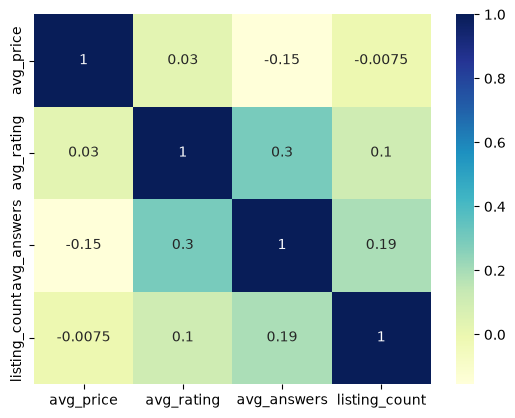

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
co_matrix = for_plot.corr(numeric_only=True)

print(co_matrix)

sns.heatmap(co_matrix, cmap="YlGnBu", annot=True)

plt.show()

**Conclusion.**
All variables show weak correlations. The strongest relationship is between avg_rating and avg_answers, was a correlation of approximately 0.30. This suggests a weak positive relationship, but it does not indicate a direct causal effect.

### Step 3. Business Insights

The analysis suggests that potentially attractive Airbnb opportunities should not be identified using price alone.
Cities with relatively high ratings and a meaningful number of answers may indicate established customer demand and positive guest experience.

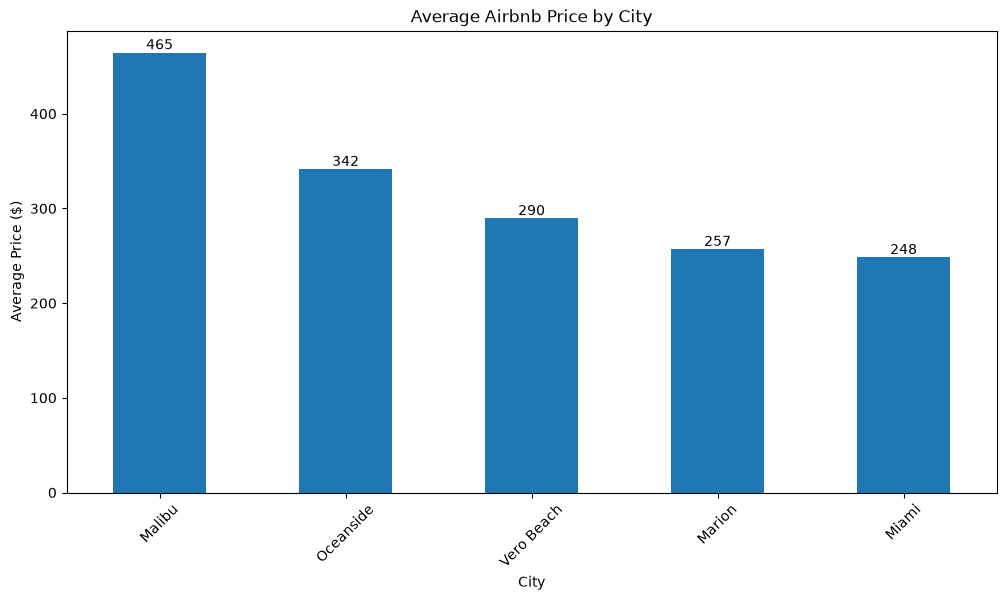

In [88]:
city_avg_price = (
    res.groupby('city')['avg_price']
      .mean()
      .sort_values(ascending=False)
)

city_avg_price.plot(
    kind='bar',
    figsize=(12, 6),
    title='Average Airbnb Price by City'
)

ax = city_avg_price.plot(
    kind='bar',
    figsize=(12, 6),
    title='Average Airbnb Price by City'
)

ax.bar_label(ax.containers[0], fmt='%.0f')

plt.xlabel('City')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.show()

The exploratory analysis showed that the United States is the most represented market in the dataset and was therefore selected for more detailed investigation.

The correlation analysis revealed only a weak positive relationship between rating and the number of answers. This indicates that customer satisfaction and customer engagement are related to some extent, but neither metric alone is sufficient to identify the best location for a new host.

In [91]:
airbnb_df.to_csv("airbnb_clear.csv", sep="\t", index=False)